# How retrieval choices influence engineering-answer reliability

## TL;DR

This notebook compares four local embedding models, three word-based
chunk sizes, three overlaps, and four top-k values on a 50-question
page-grounded engineering benchmark. A 35-question development split
selects the configuration; 15 held-out questions estimate final
retrieval performance.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT = Path.cwd()
RESULTS = PROJECT / "results"
summary = pd.read_csv(RESULTS / "retrieval_summary.csv")
details = pd.read_csv(RESULTS / "retrieval_details.csv")
inventory = pd.read_csv(RESULTS / "model_inventory.csv")
selection = json.loads((RESULTS / "selected_configuration.json").read_text())
manifest = json.loads((RESULTS / "experiment_manifest.json").read_text())

## Context and methods

A retrieval failure prevents a grounded generator from seeing the
answer, so evidence Recall@k is treated as a necessary—not
sufficient—condition for answer reliability. A relevant result must
overlap the reviewed source page and contain every manually checked
evidence term. Page-only recall is retained to expose cases where a
large chunk touches the right page but omits the answer.

Key assumptions:

- Questions are paraphrased from one legally held engineering text.
- Development Recall@5 is the primary selection metric; MRR@5 is the
  first tie-breaker.
- Test outcomes do not participate in configuration selection.
- Ollama truncation remains enabled, matching normal deployed use.

In [2]:
pd.DataFrame({
    "item": ["Questions", "Development", "Held-out test", "Configurations", "Summary points"],
    "value": [
        manifest["benchmark"]["questions"],
        manifest["benchmark"]["development"],
        manifest["benchmark"]["test"],
        len(manifest["models"]) * len(manifest["chunk_sizes_words"]) * len(manifest["overlap_words"]),
        len(manifest["models"]) * len(manifest["chunk_sizes_words"]) * len(manifest["overlap_words"]) * len(manifest["top_k"]),
    ],
})

,item,value
0,Questions,50
1,Development,35
2,Held-out test,15
3,Configurations,36
4,Summary points,144


## Data

Exact local model digests make the run reproducible. Context limits
matter because 400- and 800-word chunks can exceed the 512-token
windows of smaller encoders.

In [3]:
inventory[["model", "digest", "embedding_dimension", "context_tokens", "size_bytes"]]

,model,digest,embedding_dimension,context_tokens,size_bytes
0,all-minilm,1b226e2802dbb772b5fc32a58f103ca1804ef750133101...,384,512,45960996
1,nomic-embed-text,0a109f422b47e3a30ba2b10eca18548e944e8a23073ee3...,768,2048,274302450
2,embeddinggemma,85462619ee721b466c5927d109d4cb765861907d5417b9...,768,2048,621875917
3,mxbai-embed-large,468836162de7f81e041c43663fedbbba921dcea9b9fefe...,1024,512,669615493


## Results

In [4]:
selected = selection["selected_configuration"]
pd.Series(selected, name="selected_on_development").to_frame()

,selected_on_development
chunk_words,200
development_mrr_at_5,0.804762
development_recall_at_5,0.942857
model,embeddinggemma
overlap_words,50


In [5]:
pd.DataFrame(selection["held_out_test"]).style.format({
    "recall_at_k": "{:.1%}",
    "recall_ci_low": "{:.1%}",
    "recall_ci_high": "{:.1%}",
    "page_recall_at_k": "{:.1%}",
    "mrr_at_k": "{:.3f}",
})

,k,mrr_at_k,page_recall_at_k,questions,recall_at_k,recall_ci_high,recall_ci_low
0,1,0.667,86.7%,15,66.7%,84.8%,41.7%
1,3,0.789,100.0%,15,93.3%,98.8%,70.2%
2,5,0.802,100.0%,15,100.0%,100.0%,79.6%
3,10,0.802,100.0%,15,100.0%,100.0%,79.6%


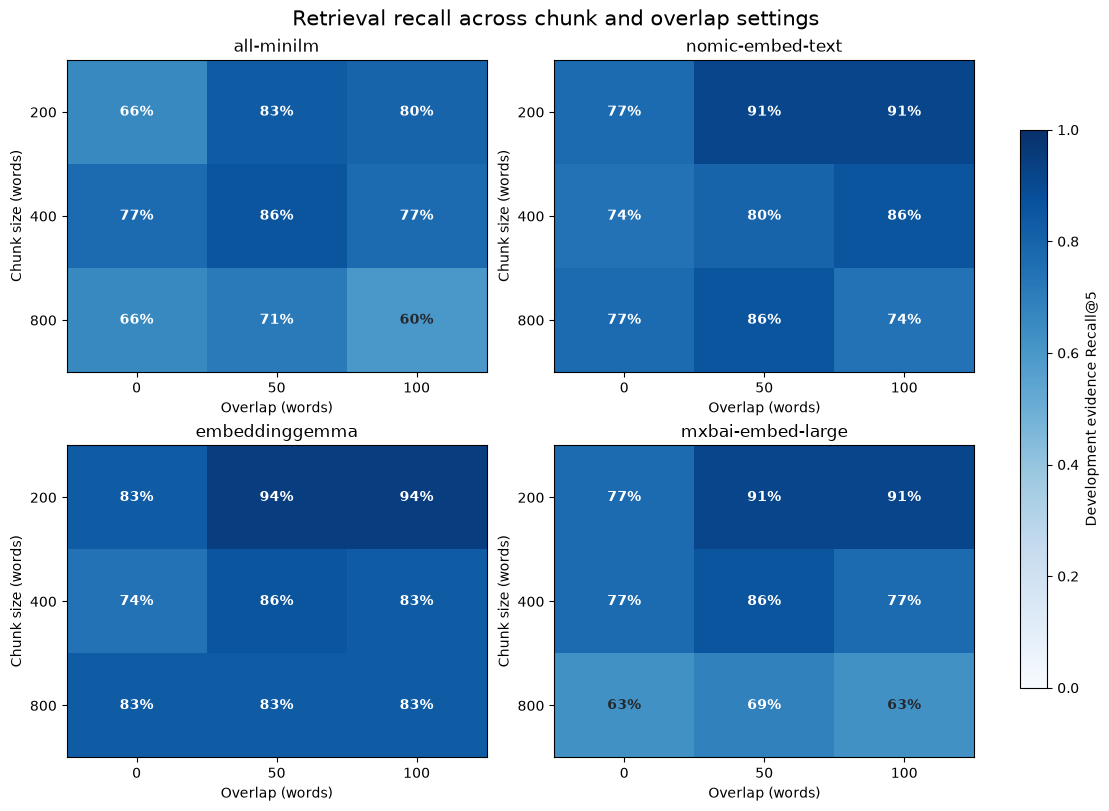

In [6]:
frame = summary[(summary.split == "development") & (summary.k == 5)]
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for axis, model in zip(axes.flat, inventory.model, strict=False):
    pivot = frame[frame.model == model].pivot(
        index="chunk_words", columns="overlap_words", values="recall_at_k"
    ).sort_index()
    image = axis.imshow(pivot, vmin=0, vmax=1, cmap="Blues", aspect="auto")
    for row in range(pivot.shape[0]):
        for column in range(pivot.shape[1]):
            value = pivot.iloc[row, column]
            axis.text(column, row, f"{value:.0%}", ha="center", va="center",
                      color="white" if value >= .65 else "#24292F", fontweight="bold")
    axis.set(title=model, xlabel="Overlap (words)", ylabel="Chunk size (words)")
    axis.set_xticks(range(len(pivot.columns)), pivot.columns)
    axis.set_yticks(range(len(pivot.index)), pivot.index)
    axis.grid(False)
fig.colorbar(image, ax=axes, label="Development evidence Recall@5", shrink=.8)
fig.suptitle("Retrieval recall across chunk and overlap settings", fontsize=15)
plt.show()

In [7]:
leaders = (frame.sort_values(
    ["model", "recall_at_k", "mrr_at_k"], ascending=[True, False, False]
).groupby("model", as_index=False).head(1))
leaders[["model", "chunk_words", "overlap_words", "recall_at_k", "mrr_at_k",
         "document_embedding_seconds", "context_truncation_risk"]].style.format({
             "recall_at_k": "{:.1%}", "mrr_at_k": "{:.3f}",
             "document_embedding_seconds": "{:.1f}",
         })

,model,chunk_words,overlap_words,recall_at_k,mrr_at_k,document_embedding_seconds,context_truncation_risk
162,all-minilm,400,50,85.7%,0.643,6.9,True
186,embeddinggemma,200,50,94.3%,0.805,79.5,False
222,mxbai-embed-large,200,50,91.4%,0.774,192.4,False
258,nomic-embed-text,200,50,91.4%,0.791,70.5,False


## Takeaways

The selected configuration and its held-out curve above are the
defensible conclusion of this run. Differences among development
and test results should be treated as sampling uncertainty, not as
proof that one model is universally superior.

This experiment supports a concrete engineering claim: retrieval
settings were chosen from held-out evidence-retrieval performance,
not intuition. It does not yet prove final answer correctness.
Answer-level factuality and citation-entailment scoring are the next
evaluation layer.

**Validation status: Ready to share with caveats.** The calculations
are reproducible and the split is respected, but the sample is small
and comes from one textbook.